# Seconds-scale signals exploration (E-002)

BTCUSDT reconstructed events, **2022 only**, for hypothesis generation (see
`HYPOTHESIS_LEDGER.md`, E-002). Nothing here is a test.

- **Mid proxy:** mean of the latest buyer- and seller-initiated trade prices.
- **Response:** mid-proxy change over τ seconds after an event, signed with the
  aggressor (positive = continuation), in bps.
- **Maker markout:** profit to the liquidity providers who were hit,
  $-s\cdot\log(\text{mid}_{t+\tau}/\text{VWAP})$, in bps. Negative = adverse
  selection.
- **States:** terciles cut on January 2022 (1 = low, 3 = high). Activity = 5-minute
  event rate relative to 24 h; volatility = 1 h / 24 h realised volatility;
  liquidity = trailing sweep realised depth relative to 24 h; spread = 30 s
  flip-gap spread relative to 24 h.

Error bars are ±2 day-clustered standard errors.

In [1]:
from pathlib import Path
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/alpha-search-matplotlib')
Path(os.environ['MPLCONFIGDIR']).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from IPython.display import display
get_ipython().run_line_magic('matplotlib', 'inline')

D = Path('/Users/petermillington/Research/market-impact-research/alpha-search/reports/seconds_signals_e002')
SERIES = ['#2a78d6', '#eb6834', '#1baf7a', '#eda100', '#e87ba4']
INK, MUTED = '#2b2b2b', '#8a8a85'
LEVELS = ['1', '2', '3-4', '5-9', '10+']
NOTIONAL = ['<1k', '1k-10k', '10k-100k', '100k-1m', '>1m']
HITS = ['1', '2', '3-5', '6-10', '11+']
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'figure.dpi': 115, 'axes.spines.top': False,
                     'axes.spines.right': False, 'grid.color': '#e6e6e3'})
pl.Config.set_float_precision(3)


def summarise(frame, keys, columns):
    rows = []
    for key, group in frame.group_by(keys):
        row = dict(zip(keys, key))
        row['n'] = int(group['n'].sum())
        for c in columns:
            daily = (group[f'sum_{c}'] / group['n']).to_numpy()
            row[c] = float(group[f'sum_{c}'].sum() / group['n'].sum())
            row[f'{c}_se'] = float(daily.std(ddof=1) / np.sqrt(len(daily)))
        rows.append(row)
    return pl.DataFrame(rows).sort(keys)

## 1. Rank IC by horizon (12 monthly values, all events sampled)

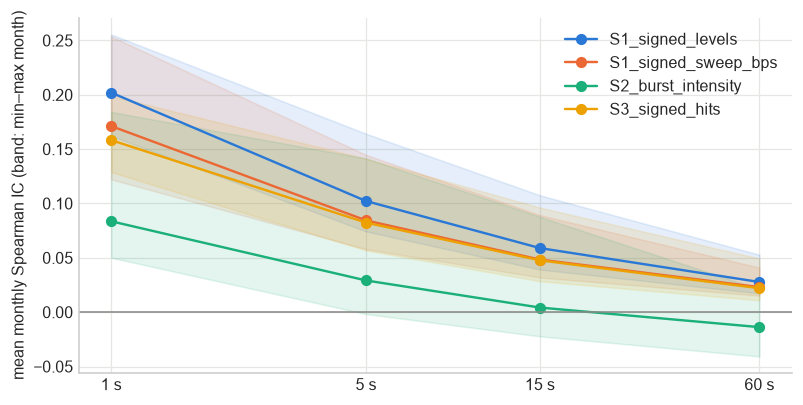

In [2]:
ic = pl.read_parquet(D / 'IC.parquet').filter(pl.col('subset') == 'all')
summary = ic.group_by('signal', 'tau').agg(pl.col('spearman_ic').mean().alias('mean_ic'),
                                           pl.col('spearman_ic').min().alias('min_month'),
                                           pl.col('spearman_ic').max().alias('max_month')).sort('signal', 'tau')
fig, ax = plt.subplots(figsize=(8, 4))
for colour, (signal, group) in zip(SERIES, summary.group_by('signal', maintain_order=True)):
    ax.plot(group['tau'], group['mean_ic'], marker='o', color=colour, label=signal[0])
    ax.fill_between(group['tau'], group['min_month'], group['max_month'], color=colour, alpha=0.12)
ax.set_xscale('log')
ax.set_xticks([1, 5, 15, 60], ['1 s', '5 s', '15 s', '60 s'])
ax.minorticks_off()
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_ylabel('mean monthly Spearman IC (band: min–max month)')
ax.legend(frameon=False, loc='upper right')
plt.show()

## 2. Sweeps: response and maker markout by price levels and notional (τ = 5 s)

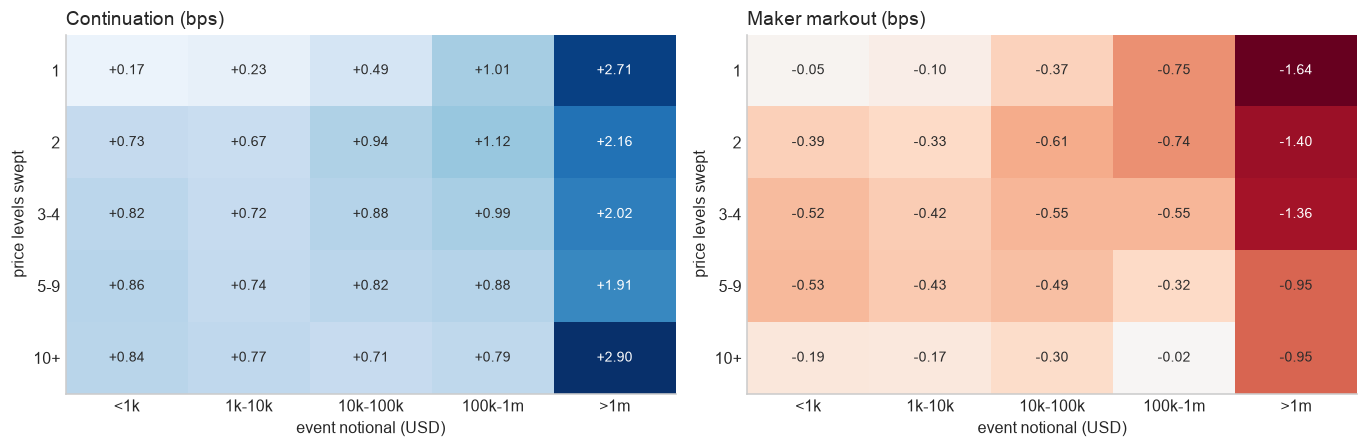

In [3]:
s1 = pl.read_parquet(D / 'S1_levels_notional.parquet').filter(pl.col('tau') == 5).group_by(
    'day', 'level_class', 'notional_class').agg(pl.col('n').sum(), pl.col('sum_response').sum(),
                                                pl.col('sum_markout').sum())
table = summarise(s1, ['level_class', 'notional_class'], ['response', 'markout'])
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, column, cmap, title in ((axes[0], 'response', 'Blues', 'Continuation (bps)'),
                                (axes[1], 'markout', 'RdBu', 'Maker markout (bps)')):
    grid = np.array([[table.filter((pl.col('level_class') == i) & (pl.col('notional_class') == j))[column][0]
                      for j in range(5)] for i in range(5)])
    limit = np.abs(grid).max()
    ax.imshow(grid, cmap=cmap, vmin=-limit if cmap == 'RdBu' else 0, vmax=limit, aspect='auto')
    for i in range(5):
        for j in range(5):
            ax.text(j, i, f'{grid[i, j]:+.2f}', ha='center', va='center', fontsize=9,
                    color='white' if abs(grid[i, j]) > 0.6 * limit else INK)
    ax.set_xticks(range(5), NOTIONAL)
    ax.set_yticks(range(5), LEVELS)
    ax.set_xlabel('event notional (USD)')
    ax.set_ylabel('price levels swept')
    ax.set_title(title, loc='left')
    ax.grid(False)
plt.tight_layout()
plt.show()

## 3. Conditioning: maker markout of multi-level sweeps by state (τ = 5 s)

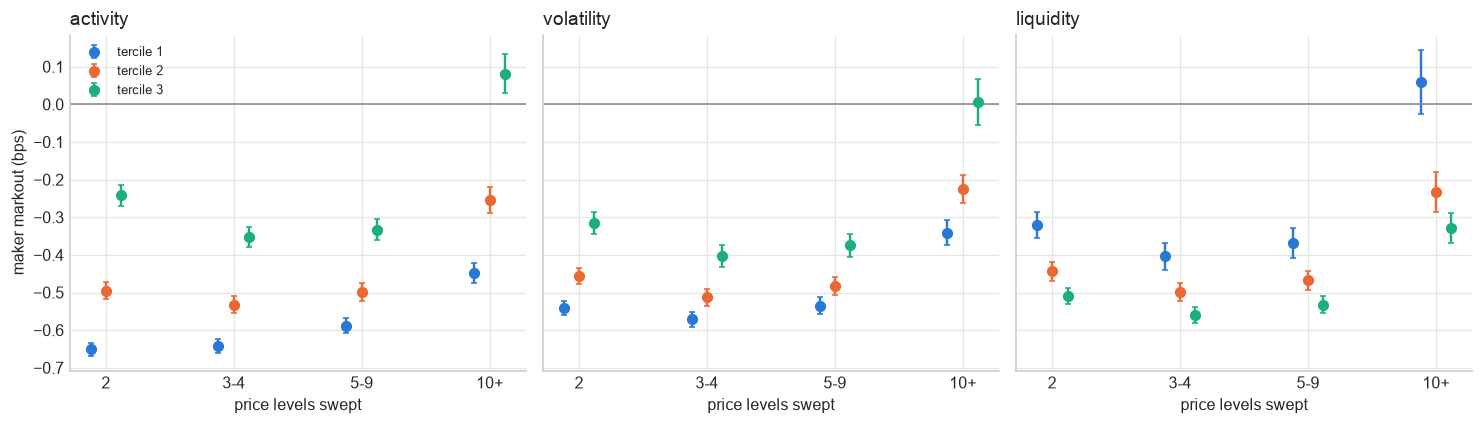

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
for ax, state in zip(axes, ['activity', 'volatility', 'liquidity']):
    frame = pl.read_parquet(D / f'S1_state_{state}.parquet').filter((pl.col('tau') == 5) & (pl.col('state') > 0))
    table = summarise(frame, ['level_class', 'state'], ['markout'])
    for colour, tercile in zip(SERIES, (1, 2, 3)):
        s = table.filter(pl.col('state') == tercile).sort('level_class')
        ax.errorbar(s['level_class'] + (tercile - 2) * 0.12, s['markout'], yerr=2 * s['markout_se'],
                    fmt='o', color=colour, capsize=2, label=f'tercile {tercile}')
    ax.axhline(0, color=MUTED, linewidth=1)
    ax.set_xticks(range(1, 5), LEVELS[1:])
    ax.set_xlabel('price levels swept')
    ax.set_title(state, loc='left')
axes[0].set_ylabel('maker markout (bps)')
axes[0].legend(frameon=False, fontsize=8)
plt.tight_layout()
plt.show()

## 4. Bursts: response by signed-intensity decile

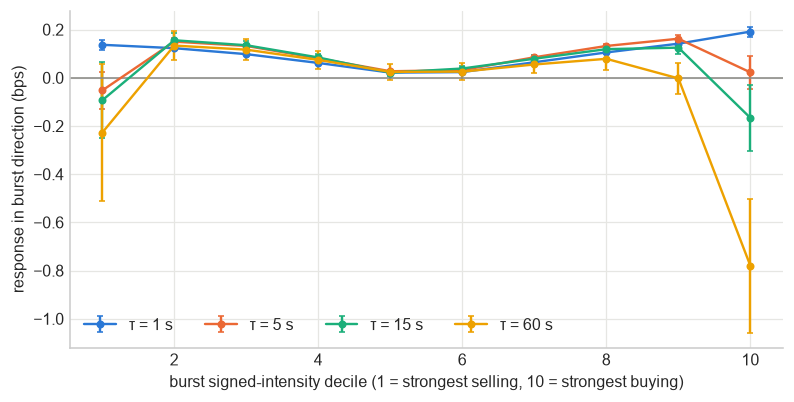

In [5]:
b = summarise(pl.read_parquet(D / 'S2_burst.parquet'), ['tau', 'burst_decile'], ['burst_response'])
fig, ax = plt.subplots(figsize=(8, 3.8))
for colour, tau in zip(SERIES, (1, 5, 15, 60)):
    s = b.filter(pl.col('tau') == tau)
    ax.errorbar(s['burst_decile'], s['burst_response'], yerr=2 * s['burst_response_se'], fmt='-o',
                color=colour, capsize=2, markersize=4, label=f'τ = {tau} s')
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xlabel('burst signed-intensity decile (1 = strongest selling, 10 = strongest buying)')
ax.set_ylabel('response in burst direction (bps)')
ax.legend(frameon=False, ncol=4)
plt.show()

## 5. Level depletion: repeated hits at an unchanged price (τ = 5 s)

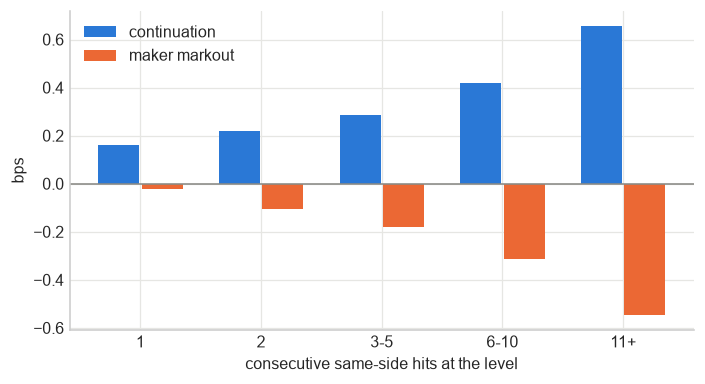

hit_class,n,response,response_se,markout,markout_se
i64,i64,f64,f64,f64,f64
0,243279261,0.161,0.003,-0.021,0.002
1,101327775,0.218,0.004,-0.104,0.002
2,89853007,0.286,0.006,-0.182,0.004
3,22339154,0.417,0.011,-0.313,0.009
4,6254566,0.658,0.025,-0.548,0.022


In [6]:
h = pl.read_parquet(D / 'S3_level_hits.parquet').filter(pl.col('tau') == 5).group_by('day', 'hit_class').agg(
    pl.col('n').sum(), pl.col('sum_response').sum(), pl.col('sum_markout').sum())
table = summarise(h, ['hit_class'], ['response', 'markout'])
fig, ax = plt.subplots(figsize=(7, 3.6))
x = np.arange(5)
ax.bar(x - 0.18, table['response'], width=0.34, color=SERIES[0], label='continuation')
ax.bar(x + 0.18, table['markout'], width=0.34, color=SERIES[1], label='maker markout')
ax.axhline(0, color=MUTED, linewidth=1)
ax.set_xticks(x, HITS)
ax.set_xlabel('consecutive same-side hits at the level')
ax.set_ylabel('bps')
ax.legend(frameon=False)
plt.show()
table

## 6. Spread state: move size and maker markout

In [7]:
summarise(pl.read_parquet(D / 'S4_spread.parquet').filter(pl.col('state') > 0), ['tau', 'state'],
          ['abs_response', 'markout'])

tau,state,n,abs_response,abs_response_se,markout,markout_se
i64,i64,i64,f64,f64,f64,f64
1,1,108263607,0.779,0.021,-0.144,0.004
1,2,221935087,0.890,0.025,-0.133,0.002
1,3,192998916,1.861,0.055,-0.057,0.008
5,1,108263607,1.941,0.047,-0.178,0.005
5,2,221935087,2.165,0.054,-0.162,0.002
…,…,…,…,…,…,…
15,2,221935087,3.807,0.090,-0.164,0.004
15,3,192998916,7.074,0.205,-0.040,0.013
60,1,108263607,7.038,0.167,-0.170,0.021
